In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style = "ticks", context =  "talk", palette = "husl")

In [9]:
import joblib

In [10]:
import cv2

In [11]:
import time

In [12]:
import re
import nltk

from nltk.corpus import stopwords

In [13]:
from wordcloud import WordCloud

In [14]:
from sklearn.model_selection import train_test_split

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [16]:
from sklearn.linear_model import LogisticRegression

In [17]:
from sklearn.svm import LinearSVC

In [18]:
from sklearn.naive_bayes import MultinomialNB

In [19]:
from sklearn.ensemble import GradientBoostingClassifier

In [20]:
from sklearn.ensemble import RandomForestClassifier

In [21]:
from sklearn.metrics import f1_score, classification_report

In [22]:
from sklearn.metrics import confusion_matrix

In [23]:
import tqdm

In [24]:
from imblearn.metrics import classification_report_imbalanced, geometric_mean_score

In [25]:
X_tr = pd.read_csv("../../../002_Dataset_ALL/X_train_update.csv", index_col=0)
y_tr = pd.read_csv("../../../002_Dataset_ALL/Y_train_CVw08PX.csv", index_col=0)

In [26]:
X_tr

,designation,description,productid,imageid
0,Olivia: Personalisiertes Notizbuch / 150 Seite...,NaN,3804725264,1263597046
1,Journal Des Arts (Le) N° 133 Du 28/09/2001 - L...,NaN,436067568,1008141237
2,Grand Stylet Ergonomique Bleu Gamepad Nintendo...,PILOT STYLE Touch Pen de marque Speedlink est ...,201115110,938777978
3,Peluche Donald - Europe - Disneyland 2000 (Mar...,NaN,50418756,457047496
4,La Guerre Des Tuques,Luc a des id&eacute;es de grandeur. Il veut or...,278535884,1077757786
...,...,...,...,...
84911,The Sims [ Import Anglais ],NaN,206719094,941495734
84912,Kit piscine acier NEVADA déco pierre Ø 3.50m x...,<b>Description complète :</b><br />Kit piscine...,3065095706,1188462883
84913,Journal Officiel De La Republique Francaise N°...,NaN,440707564,1009325617
84914,Table Basse Bois De Récupération Massif Base B...,<p>Cette table basse a un design unique et con...,3942400296,1267353403


In [27]:
# Analyse de la variable cibe y_train
y_tr

,prdtypecode
0,10
1,2280
2,50
3,1280
4,2705
...,...
84911,40
84912,2583
84913,2280
84914,1560


In [28]:
# vérifier les catégories de y_train
print("le nombre total des classes de prdtypecode: \n", y_tr['prdtypecode'].nunique())
print("les classes de prdtypecode : \n", y_tr.value_counts())

le nombre total des classes de prdtypecode: 
 27
les classes de prdtypecode : 
 prdtypecode
2583           10209
1560            5073
1300            5045
2060            4993
2522            4989
1280            4870
2403            4774
2280            4760
1920            4303
1160            3953
1320            3241
10              3116
2705            2761
1140            2671
2582            2589
40              2508
2585            2496
1302            2491
1281            2070
50              1681
2462            1421
2905             872
60               832
2220             824
1301             807
1940             803
1180             764
Name: count, dtype: int64


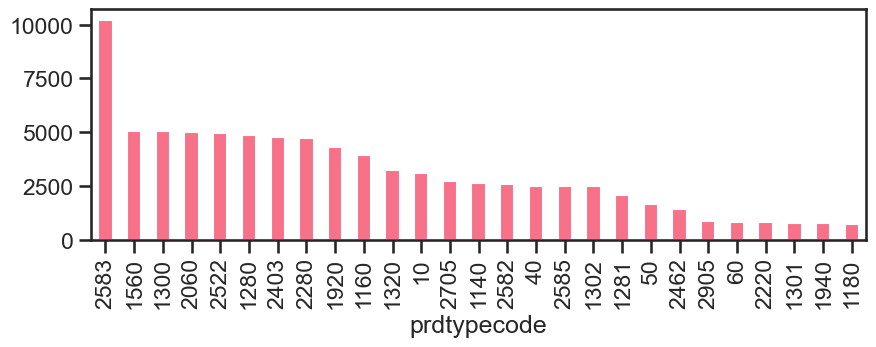

In [29]:
# Vérifier la distribution des prdtypecode :
y_tr['prdtypecode'].value_counts().plot(kind='bar', figsize=(10,3));

In [30]:
# fusion de X_tr et y_tr
fusion = y_tr.merge(X_tr, left_index=True, right_index=True)
display(X_tr.head(2))
display(X_tr.tail(2))
display(y_tr.head(2))
display(y_tr.tail(2))
display(fusion)

,designation,description,productid,imageid
0,Olivia: Personalisiertes Notizbuch / 150 Seite...,NaN,3804725264,1263597046
1,Journal Des Arts (Le) N° 133 Du 28/09/2001 - L...,NaN,436067568,1008141237


,designation,description,productid,imageid
84914,Table Basse Bois De Récupération Massif Base B...,<p>Cette table basse a un design unique et con...,3942400296,1267353403
84915,Gomme De Collection 2 Gommes Pinguin Glace Ver...,NaN,57203227,684671297


,prdtypecode
0,10
1,2280


,prdtypecode
84914,1560
84915,2522


,prdtypecode,designation,description,productid,imageid
0,10,Olivia: Personalisiertes Notizbuch / 150 Seite...,NaN,3804725264,1263597046
1,2280,Journal Des Arts (Le) N° 133 Du 28/09/2001 - L...,NaN,436067568,1008141237
2,50,Grand Stylet Ergonomique Bleu Gamepad Nintendo...,PILOT STYLE Touch Pen de marque Speedlink est ...,201115110,938777978
3,1280,Peluche Donald - Europe - Disneyland 2000 (Mar...,NaN,50418756,457047496
4,2705,La Guerre Des Tuques,Luc a des id&eacute;es de grandeur. Il veut or...,278535884,1077757786
...,...,...,...,...,...
84911,40,The Sims [ Import Anglais ],NaN,206719094,941495734
84912,2583,Kit piscine acier NEVADA déco pierre Ø 3.50m x...,<b>Description complète :</b><br />Kit piscine...,3065095706,1188462883
84913,2280,Journal Officiel De La Republique Francaise N°...,NaN,440707564,1009325617
84914,1560,Table Basse Bois De Récupération Massif Base B...,<p>Cette table basse a un design unique et con...,3942400296,1267353403


In [31]:
# afficher les lignes concernant le prdtypecode le plus fréquent (2583)
fusion.loc[fusion['prdtypecode'] == 2583]
# remarque: ces produits sont liés à la 'piscine'

,prdtypecode,designation,description,productid,imageid
20,2583,Kit de désinfection pour piscines enfants 20990,NaN,3936362802,1268740880
39,2583,Bouée gonflable River tube - OOGARDEN,Bouée gonflable River tube en PVC idéale pour ...,3147314797,1225887302
53,2583,Testeur électronique de pH,Utilisation du Testeur électronique de pHGrâce...,207151480,941622055
58,2583,Pompe de filtration Speck Badu 95,NaN,4128438373,1295960377
64,2583,AstralCom 1 CV Mono de DAB - Surpresseur piscine,Tension (V) : Monophasé - 230 V Puissance : 1...,1857269337,1105831362
...,...,...,...,...,...
84874,2583,Skimmer standard petite meurtrière - Vis PARKE...,Type de pièces : Skimmer Revêtement : Liner ...,2151623756,1128623127
84887,2583,Linxor - Bâche à Bulles 300 microns piscine 2m...,NaN,1951685693,1317940307
84905,2583,Bâche été pour piscine Lili Ø 255 m,<p>La <strong>bâche été</strong> permet d&#39;...,1886035156,1109239046
84909,2583,espa - kit complet de nage à contre courant 39...,espa espa - kit complet de nage à contre coura...,853455937,1043841028


In [32]:
fusion.info()

<class 'pandas.core.frame.DataFrame'>
Index: 84916 entries, 0 to 84915
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   prdtypecode  84916 non-null  int64 
 1   designation  84916 non-null  object
 2   description  55116 non-null  object
 3   productid    84916 non-null  int64 
 4   imageid      84916 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 3.9+ MB


In [33]:
essai4 = fusion.copy()
print(essai4.info())
display(essai4.head(3))

<class 'pandas.core.frame.DataFrame'>
Index: 84916 entries, 0 to 84915
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   prdtypecode  84916 non-null  int64 
 1   designation  84916 non-null  object
 2   description  55116 non-null  object
 3   productid    84916 non-null  int64 
 4   imageid      84916 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 3.9+ MB
None


,prdtypecode,designation,description,productid,imageid
0,10,Olivia: Personalisiertes Notizbuch / 150 Seite...,NaN,3804725264,1263597046
1,2280,Journal Des Arts (Le) N° 133 Du 28/09/2001 - L...,NaN,436067568,1008141237
2,50,Grand Stylet Ergonomique Bleu Gamepad Nintendo...,PILOT STYLE Touch Pen de marque Speedlink est ...,201115110,938777978


In [29]:
# ---------------------------
# MODEL ML simple pour TEXTE
# ---------------------------
X_text = essai4["designation"]
y = essai4["prdtypecode"]
X_train_text, X_test_text, y_train, y_test = train_test_split(X_text, y, test_size=0.2, stratify=y, random_state=42)


In [30]:
# Etape 3: Représentation du texte
# Première approche : texte brut sans nettoyage(Pas de stopwords, pas de regex — texte brut pour commencer)
tfidf = TfidfVectorizer(max_features=20000)
X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)

In [31]:
# Étape 4 — Modèles classiques à tester
# 4.1 Logistic Regression (multiclasse)
# ---------------
#La durée de l'entrainement + prediction
start = time.time()

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_tfidf, y_train)
y_pred_lr = lr.predict(X_test_tfidf)

end =time.time()
print("Durée = ", (end-start)/60)

Durée =  0.6154373447100322


In [32]:
# 4.1 Logistic Regression (multiclasse)
print("F1-score LogisticRegression: ", f1_score(y_test, y_pred_lr, average="weighted"))
print("Rapport Classification LogisticRegression: \n", classification_report_imbalanced(y_test, y_pred_lr))
display("Matrice confusion LogisticRegression: \n",pd.crosstab(y_test, y_pred_lr, rownames=['Reel'], colnames=['Predit']))

F1-score LogisticRegression:  0.7987457731563118
Rapport Classification LogisticRegression: 
                    pre       rec       spe        f1       geo       iba       sup

         10       0.48      0.49      0.98      0.48      0.69      0.45       623
         40       0.75      0.65      0.99      0.70      0.81      0.63       502
         50       0.79      0.77      1.00      0.78      0.87      0.75       336
         60       0.90      0.73      1.00      0.81      0.85      0.71       166
       1140       0.78      0.77      0.99      0.77      0.87      0.74       534
       1160       0.91      0.94      1.00      0.92      0.97      0.93       791
       1180       0.77      0.44      1.00      0.56      0.66      0.41       153
       1280       0.68      0.74      0.98      0.71      0.85      0.71       974
       1281       0.70      0.43      1.00      0.53      0.65      0.40       414
       1300       0.96      0.95      1.00      0.96      0.97      0.94   

'Matrice confusion LogisticRegression: \n'

Predit,10,40,50,60,1140,1160,1180,1280,1281,1300,...,2220,2280,2403,2462,2522,2582,2583,2585,2705,2905
Reel,,,,,,,,,,,,,,,,,,,,,
10,304,9,1,0,1,1,0,11,1,1,...,0,73,48,1,3,0,4,0,163,0
40,36,328,19,2,8,6,2,20,8,1,...,0,12,5,14,2,1,2,2,22,0
50,2,15,258,8,6,2,0,10,0,2,...,0,3,0,10,1,0,5,3,1,0
60,0,13,7,121,1,0,0,2,2,1,...,0,0,0,18,0,0,0,0,1,0
1140,9,10,4,0,409,9,6,28,4,0,...,0,6,19,1,4,1,1,1,12,0
1160,7,3,1,0,4,746,0,4,4,2,...,1,1,4,0,2,0,2,1,8,0
1180,16,2,1,0,8,9,67,13,6,2,...,0,3,5,1,4,2,1,0,5,0
1280,10,10,1,0,49,5,1,723,30,21,...,4,6,4,1,9,9,11,3,8,0
1281,17,10,0,0,14,23,7,94,178,0,...,0,10,3,6,6,1,5,0,20,0


In [33]:
# Étape 4 — Modèles classiques à tester (suite)
# 4.2 Linear SVM
# -------------
#La durée de l'entrainement + prediction
start = time.time()

svc = LinearSVC()
svc.fit(X_train_tfidf, y_train)
y_pred_svc = svc.predict(X_test_tfidf)

end =time.time()
print("Durée = ", (end-start)/60)

Durée =  0.05222887595494588


In [34]:
# 4.2 Linear SVM
print("F1-score LinearSVC: ", f1_score(y_test, y_pred_svc, average="weighted"))
print("Rapport Classification LinearSVC: \n", classification_report_imbalanced(y_test, y_pred_svc))
display("Matrice confusion LinearSVC: \n",pd.crosstab(y_test, y_pred_svc, rownames=['Reel'], colnames=['Predit']))

F1-score LinearSVC:  0.8106975109917467
Rapport Classification LinearSVC: 
                    pre       rec       spe        f1       geo       iba       sup

         10       0.52      0.47      0.98      0.49      0.68      0.43       623
         40       0.75      0.68      0.99      0.71      0.82      0.66       502
         50       0.78      0.82      1.00      0.80      0.91      0.81       336
         60       0.90      0.79      1.00      0.84      0.89      0.77       166
       1140       0.73      0.77      0.99      0.75      0.88      0.75       534
       1160       0.93      0.95      1.00      0.94      0.98      0.95       791
       1180       0.74      0.56      1.00      0.64      0.75      0.54       153
       1280       0.71      0.71      0.98      0.71      0.83      0.68       974
       1281       0.62      0.52      0.99      0.57      0.72      0.50       414
       1300       0.95      0.96      1.00      0.96      0.98      0.95      1009
       130

'Matrice confusion LinearSVC: \n'

Predit,10,40,50,60,1140,1160,1180,1280,1281,1300,...,2220,2280,2403,2462,2522,2582,2583,2585,2705,2905
Reel,,,,,,,,,,,,,,,,,,,,,
10,290,13,2,0,5,3,1,9,6,4,...,2,70,47,1,9,2,4,4,140,0
40,21,342,17,5,16,4,4,13,9,3,...,0,4,5,18,4,0,1,3,21,0
50,1,12,277,5,5,0,0,5,1,1,...,0,4,0,9,0,1,2,4,1,0
60,0,5,5,131,0,0,0,2,2,0,...,0,0,0,20,0,0,0,0,1,0
1140,4,9,3,0,413,8,8,31,7,4,...,0,6,10,1,4,0,1,0,6,0
1160,2,5,3,0,2,755,0,4,5,1,...,0,2,1,0,2,0,0,1,6,0
1180,7,4,1,0,6,1,86,12,15,1,...,0,1,1,1,3,2,1,1,7,0
1280,6,11,6,0,59,3,3,689,50,23,...,4,5,6,1,11,7,6,4,7,0
1281,10,8,0,0,14,15,6,89,217,0,...,0,7,3,5,3,1,3,0,14,0


In [35]:
# Étape 4 — Modèles classiques à tester (suite)
# 4.3 Naive Bayes (MultinomialNB) - apparemment rapide, efficace sur texte
# -------------
#La durée de l'entrainement + prediction
start = time.time()

nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)
y_pred_nb = nb.predict(X_test_tfidf)

end =time.time()
print("Durée = ", (end-start)/60)

Durée =  0.0014648556709289551


In [36]:
# 4.3 Naive Bayes (MultinomialNB) - rapide
print("F1-score Naive Bayes: ", f1_score(y_test, y_pred_nb, average="weighted"))
print("Rapport Classification Naive Bayes: \n", classification_report_imbalanced(y_test, y_pred_nb))
display("Matrice confusion Naive Bayes: \n",pd.crosstab(y_test, y_pred_nb, rownames=['Reel'], colnames=['Predit']))

F1-score Naive Bayes:  0.7058371050580391
Rapport Classification Naive Bayes: 
                    pre       rec       spe        f1       geo       iba       sup

         10       0.70      0.29      1.00      0.41      0.54      0.27       623
         40       0.70      0.56      0.99      0.62      0.75      0.54       502
         50       0.73      0.66      1.00      0.69      0.81      0.64       336
         60       0.88      0.67      1.00      0.76      0.82      0.65       166
       1140       0.75      0.69      0.99      0.72      0.83      0.67       534
       1160       0.87      0.96      0.99      0.91      0.98      0.95       791
       1180       0.97      0.18      1.00      0.31      0.43      0.17       153
       1280       0.53      0.62      0.97      0.57      0.78      0.58       974
       1281       0.84      0.23      1.00      0.36      0.48      0.21       414
       1300       0.76      0.96      0.98      0.85      0.97      0.94      1009
      

'Matrice confusion Naive Bayes: \n'

Predit,10,40,50,60,1140,1160,1180,1280,1281,1300,...,2220,2280,2403,2462,2522,2582,2583,2585,2705,2905
Reel,,,,,,,,,,,,,,,,,,,,,
10,181,8,0,0,1,1,0,17,0,10,...,0,199,138,1,13,0,17,0,35,0
40,17,283,32,3,16,13,0,23,2,15,...,0,27,22,3,2,0,21,0,5,0
50,1,15,222,10,8,1,0,13,0,19,...,0,0,0,15,4,0,11,1,0,0
60,0,17,14,112,2,0,0,2,1,1,...,0,1,0,14,0,0,0,0,0,0
1140,1,9,3,0,371,12,0,57,2,2,...,0,16,25,1,6,1,9,0,1,0
1160,2,0,1,0,4,760,0,5,2,1,...,0,5,3,0,3,0,4,0,1,0
1180,5,4,0,1,23,16,28,16,4,2,...,0,7,7,0,8,0,9,0,1,0
1280,4,5,1,1,40,4,0,607,3,189,...,0,7,8,0,10,1,27,1,1,0
1281,13,13,0,0,12,32,1,137,95,6,...,0,31,17,1,20,0,15,0,3,1


In [37]:
# Étape 4 — Modèles classiques à tester (suite)
# 4.4 GradientBoostingClassifier 
# -------------
#La durée de l'entrainement + prediction
start = time.time()

gb = GradientBoostingClassifier()
gb.fit(X_train_tfidf, y_train)
y_pred_gb = gb.predict(X_test_tfidf)

end =time.time()
print("Durée = ", (end-start)/60)

Durée =  14.30751212835312


In [38]:
# 4.4 GradientBoostingClassifier - TROP LONG - 15min
print("F1-score GradientBoosting: ", f1_score(y_test, y_pred_gb, average="weighted"))
print("Rapport Classification GradientBoosting: \n", classification_report_imbalanced(y_test, y_pred_gb))
display("Matrice confusion GradientBoosting: \n",pd.crosstab(y_test, y_pred_gb, rownames=['Reel'], colnames=['Predit']))

F1-score GradientBoosting:  0.7340507667172601
Rapport Classification GradientBoosting: 
                    pre       rec       spe        f1       geo       iba       sup

         10       0.43      0.34      0.98      0.38      0.58      0.31       623
         40       0.70      0.55      0.99      0.62      0.74      0.52       502
         50       0.74      0.65      1.00      0.69      0.80      0.62       336
         60       0.81      0.77      1.00      0.79      0.87      0.75       166
       1140       0.79      0.71      0.99      0.75      0.84      0.69       534
       1160       0.91      0.87      1.00      0.89      0.93      0.86       791
       1180       0.59      0.47      1.00      0.52      0.68      0.44       153
       1280       0.73      0.65      0.99      0.68      0.80      0.61       974
       1281       0.63      0.41      0.99      0.50      0.64      0.39       414
       1300       0.96      0.93      1.00      0.95      0.96      0.92      1

'Matrice confusion GradientBoosting: \n'

Predit,10,40,50,60,1140,1160,1180,1280,1281,1300,...,2220,2280,2403,2462,2522,2582,2583,2585,2705,2905
Reel,,,,,,,,,,,,,,,,,,,,,
10,210,17,0,0,1,1,5,1,0,1,...,2,62,40,5,4,2,98,1,162,1
40,40,275,21,2,5,4,2,5,20,1,...,0,8,3,22,1,1,56,0,24,0
50,3,7,218,12,4,1,0,7,6,2,...,0,4,0,21,2,0,31,1,1,0
60,5,5,9,127,0,0,0,2,3,0,...,0,2,0,9,0,0,4,0,0,0
1140,8,8,5,1,381,6,11,15,6,2,...,0,8,17,3,3,0,35,0,15,0
1160,7,5,1,1,2,691,0,1,7,2,...,0,13,3,1,0,0,50,0,5,0
1180,7,1,0,0,8,7,72,5,5,1,...,0,3,3,1,0,1,26,0,6,0
1280,15,13,2,4,46,6,3,629,24,8,...,6,8,7,3,7,5,92,2,7,0
1281,21,5,1,0,7,14,8,74,171,0,...,0,12,6,6,3,0,35,0,22,0


In [39]:
# Étape 4 — Modèles classiques à tester (suite)
# 4.5 Random Forest 
# -------------
#La durée de l'entrainement + prediction
start = time.time()

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_tfidf, y_train)
y_pred_rf = rf.predict(X_test_tfidf)

end =time.time()
print("Durée = ", (end-start)/60)

Durée =  10.470973579088847


In [40]:
# 4.5 Random Forest
print("F1-score Random Forest: ", f1_score(y_test, y_pred_rf, average="weighted"))
print("Rapport Classification Random Forest: \n", classification_report_imbalanced(y_test, y_pred_rf))
display("Matrice confusion Random Forest: \n",pd.crosstab(y_test, y_pred_rf, rownames=['Reel'], colnames=['Predit']))

F1-score Random Forest:  0.7753240956045417
Rapport Classification Random Forest: 
                    pre       rec       spe        f1       geo       iba       sup

         10       0.36      0.46      0.97      0.40      0.67      0.42       623
         40       0.75      0.61      0.99      0.67      0.78      0.58       502
         50       0.81      0.74      1.00      0.77      0.86      0.72       336
         60       0.94      0.82      1.00      0.87      0.90      0.80       166
       1140       0.76      0.74      0.99      0.75      0.85      0.71       534
       1160       0.90      0.92      1.00      0.91      0.96      0.91       791
       1180       0.83      0.52      1.00      0.64      0.72      0.50       153
       1280       0.70      0.61      0.98      0.65      0.77      0.58       974
       1281       0.60      0.42      0.99      0.49      0.65      0.39       414
       1300       0.88      0.95      0.99      0.91      0.97      0.93      1009
  

'Matrice confusion Random Forest: \n'

Predit,10,40,50,60,1140,1160,1180,1280,1281,1300,...,2220,2280,2403,2462,2522,2582,2583,2585,2705,2905
Reel,,,,,,,,,,,,,,,,,,,,,
10,287,11,0,0,1,4,3,1,1,0,...,0,56,41,2,3,0,4,0,203,0
40,69,304,21,4,5,5,0,11,12,0,...,0,6,6,15,1,0,2,1,29,0
50,8,14,248,5,5,0,0,2,3,5,...,0,0,1,20,2,2,6,0,3,0
60,1,5,3,136,3,0,0,0,2,2,...,0,1,0,13,0,0,0,0,0,0
1140,18,9,5,0,393,9,5,19,9,1,...,1,8,22,1,3,0,3,1,17,0
1160,20,7,0,0,3,731,0,3,3,2,...,0,5,5,0,0,0,1,0,10,0
1180,15,2,1,0,9,3,80,6,12,2,...,0,1,5,1,2,1,0,0,10,0
1280,40,4,3,0,47,7,2,594,48,87,...,2,7,11,3,11,6,12,4,17,0
1281,26,13,0,0,8,17,3,86,174,1,...,0,6,5,9,8,0,3,0,28,0


In [41]:
# Après avoir comparé f1 et geo des 4 modèles Logistic Regression, SVM, Naive Bayes, Gradient Boosting et Random Forest,
# on choisit Logistic Regression et SVM car ils présentent de meilleurs résultat et ils sont rapide (1 à 2 minutes d'entrainement)

In [35]:
# -------------------------------
# NETTOYAGE 1: tout en minuscules
# -------------------------------
def clean_text_lower(text):
    """
    Nettoyage niveau 1 : met tout en minuscules.
    """
    return text.lower()

In [36]:
# -------------------------------
# NETTOYAGE 1: tout en minuscules
# -------------------------------
essai4["designation_clean1"] = essai4["designation"].apply(clean_text_lower)
essai4.head(3)

,prdtypecode,designation,description,productid,imageid,designation_clean1
0,10,Olivia: Personalisiertes Notizbuch / 150 Seite...,NaN,3804725264,1263597046,olivia: personalisiertes notizbuch / 150 seite...
1,2280,Journal Des Arts (Le) N° 133 Du 28/09/2001 - L...,NaN,436067568,1008141237,journal des arts (le) n° 133 du 28/09/2001 - l...
2,50,Grand Stylet Ergonomique Bleu Gamepad Nintendo...,PILOT STYLE Touch Pen de marque Speedlink est ...,201115110,938777978,grand stylet ergonomique bleu gamepad nintendo...


In [44]:
# -------------------------------
# NETTOYAGE 1: tout en minuscules
# -------------------------------
# Refaire la séparation X et y
X_text_1 = essai4["designation_clean1"]
y = essai4["prdtypecode"]
X_train_text_1, X_test_text_1, y_train, y_test = train_test_split(X_text_1, y, test_size=0.2, stratify=y, random_state=42)

In [45]:
# -------------------------------
# NETTOYAGE 1: tout en minuscules
# -------------------------------
# Refaire Etape 3: Représentation du texte
# NETTOYAGE 1 : tout en minuscules
tfidf_1 = TfidfVectorizer(max_features=20000)
X_train_tfidf_1 = tfidf_1.fit_transform(X_train_text_1)
X_test_tfidf_1 = tfidf_1.transform(X_test_text_1)

In [46]:
# -------------------------------
# NETTOYAGE 1: tout en minuscules
# -------------------------------
# Refaire Étape 4 — Modèles classiques à tester
# 4.1 Logistic Regression (multiclasse)

lr_1 = LogisticRegression(max_iter=1000)
lr_1.fit(X_train_tfidf_1, y_train)
y_pred_lr_1 = lr_1.predict(X_test_tfidf_1)

In [47]:
# -------------------------------
# NETTOYAGE 1: tout en minuscules
# -------------------------------
# 4.1 Logistic Regression (multiclasse)
print("F1-score LogisticRegression: ", f1_score(y_test, y_pred_lr_1, average="weighted"))
print("Rapport Classification LogisticRegression: \n", classification_report_imbalanced(y_test, y_pred_lr_1))
display("Matrice confusion LogisticRegression: \n",pd.crosstab(y_test, y_pred_lr_1, rownames=['Reel'], colnames=['Predit']))

F1-score LogisticRegression:  0.7987457731563118
Rapport Classification LogisticRegression: 
                    pre       rec       spe        f1       geo       iba       sup

         10       0.48      0.49      0.98      0.48      0.69      0.45       623
         40       0.75      0.65      0.99      0.70      0.81      0.63       502
         50       0.79      0.77      1.00      0.78      0.87      0.75       336
         60       0.90      0.73      1.00      0.81      0.85      0.71       166
       1140       0.78      0.77      0.99      0.77      0.87      0.74       534
       1160       0.91      0.94      1.00      0.92      0.97      0.93       791
       1180       0.77      0.44      1.00      0.56      0.66      0.41       153
       1280       0.68      0.74      0.98      0.71      0.85      0.71       974
       1281       0.70      0.43      1.00      0.53      0.65      0.40       414
       1300       0.96      0.95      1.00      0.96      0.97      0.94   

'Matrice confusion LogisticRegression: \n'

Predit,10,40,50,60,1140,1160,1180,1280,1281,1300,...,2220,2280,2403,2462,2522,2582,2583,2585,2705,2905
Reel,,,,,,,,,,,,,,,,,,,,,
10,304,9,1,0,1,1,0,11,1,1,...,0,73,48,1,3,0,4,0,163,0
40,36,328,19,2,8,6,2,20,8,1,...,0,12,5,14,2,1,2,2,22,0
50,2,15,258,8,6,2,0,10,0,2,...,0,3,0,10,1,0,5,3,1,0
60,0,13,7,121,1,0,0,2,2,1,...,0,0,0,18,0,0,0,0,1,0
1140,9,10,4,0,409,9,6,28,4,0,...,0,6,19,1,4,1,1,1,12,0
1160,7,3,1,0,4,746,0,4,4,2,...,1,1,4,0,2,0,2,1,8,0
1180,16,2,1,0,8,9,67,13,6,2,...,0,3,5,1,4,2,1,0,5,0
1280,10,10,1,0,49,5,1,723,30,21,...,4,6,4,1,9,9,11,3,8,0
1281,17,10,0,0,14,23,7,94,178,0,...,0,10,3,6,6,1,5,0,20,0


In [48]:
# -------------------------------
# NETTOYAGE 1: tout en minuscules
# -------------------------------
# 4.2 Linear SVM
svc_1 = LinearSVC()
svc_1.fit(X_train_tfidf_1, y_train)
y_pred_svc_1 = svc_1.predict(X_test_tfidf_1)


In [49]:
# -------------------------------
# NETTOYAGE 1: tout en minuscules
# -------------------------------
# 4.2 Linear SVM
print("F1-score Linear SVC (SVM): ", f1_score(y_test, y_pred_svc_1, average="weighted"))
print("Rapport Classification Linear SVC (SVM)- NETTOYAGE 1: tout en minuscules:")
print(classification_report_imbalanced(y_test, y_pred_svc_1))
print("Matrice confusion Linear SVC (SVM) NETTOYAGE 1: tout en minuscules:",
display(pd.crosstab(y_test, y_pred_svc_1, rownames=['Reel'], colnames=['Predit'])))

F1-score Linear SVC (SVM):  0.8106975109917467
Rapport Classification Linear SVC (SVM)- NETTOYAGE 1: tout en minuscules:
                   pre       rec       spe        f1       geo       iba       sup

         10       0.52      0.47      0.98      0.49      0.68      0.43       623
         40       0.75      0.68      0.99      0.71      0.82      0.66       502
         50       0.78      0.82      1.00      0.80      0.91      0.81       336
         60       0.90      0.79      1.00      0.84      0.89      0.77       166
       1140       0.73      0.77      0.99      0.75      0.88      0.75       534
       1160       0.93      0.95      1.00      0.94      0.98      0.95       791
       1180       0.74      0.56      1.00      0.64      0.75      0.54       153
       1280       0.71      0.71      0.98      0.71      0.83      0.68       974
       1281       0.62      0.52      0.99      0.57      0.72      0.50       414
       1300       0.95      0.96      1.00      

Predit,10,40,50,60,1140,1160,1180,1280,1281,1300,...,2220,2280,2403,2462,2522,2582,2583,2585,2705,2905
Reel,,,,,,,,,,,,,,,,,,,,,
10,290,13,2,0,5,3,1,9,6,4,...,2,70,47,1,9,2,4,4,140,0
40,21,342,17,5,16,4,4,13,9,3,...,0,4,5,18,4,0,1,3,21,0
50,1,12,277,5,5,0,0,5,1,1,...,0,4,0,9,0,1,2,4,1,0
60,0,5,5,131,0,0,0,2,2,0,...,0,0,0,20,0,0,0,0,1,0
1140,4,9,3,0,413,8,8,31,7,4,...,0,6,10,1,4,0,1,0,6,0
1160,2,5,3,0,2,755,0,4,5,1,...,0,2,1,0,2,0,0,1,6,0
1180,7,4,1,0,6,1,86,12,15,1,...,0,1,1,1,3,2,1,1,7,0
1280,6,11,6,0,59,3,3,689,50,23,...,4,5,6,1,11,7,6,4,7,0
1281,10,8,0,0,14,15,6,89,217,0,...,0,7,3,5,3,1,3,0,14,0


Matrice confusion Linear SVC (SVM) NETTOYAGE 1: tout en minuscules: None


In [37]:
# -------------------------------
# NETTOYAGE 2: minuscules + suppression des chiffres et caractères spéciaux
# -------------------------------
def clean_text_letters_only(text):
    """
    Nettoyage niveau 2 :
    - met tout en minuscules
    - garde uniquement les lettres (accentuées incluses) et les espaces
    - supprime les chiffres et caractères spéciaux
    """
    text = text.lower()
    # Conserve lettres latines (a-z) + lettres accentuées étendues + espaces
    text = re.sub(r"[^a-zA-ZÀ-ÿ\s]", " ", text)
    # Supprime les espaces multiples
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [38]:
# -------------------------------
# NETTOYAGE 2: minuscules + suppression des chiffres et caractères spéciaux
# -------------------------------
essai4["designation_clean2"] = essai4["designation"].apply(clean_text_letters_only)
essai4.head(3)

,prdtypecode,designation,description,productid,imageid,designation_clean1,designation_clean2
0,10,Olivia: Personalisiertes Notizbuch / 150 Seite...,NaN,3804725264,1263597046,olivia: personalisiertes notizbuch / 150 seite...,olivia personalisiertes notizbuch seiten punkt...
1,2280,Journal Des Arts (Le) N° 133 Du 28/09/2001 - L...,NaN,436067568,1008141237,journal des arts (le) n° 133 du 28/09/2001 - l...,journal des arts le n du l art et son marche s...
2,50,Grand Stylet Ergonomique Bleu Gamepad Nintendo...,PILOT STYLE Touch Pen de marque Speedlink est ...,201115110,938777978,grand stylet ergonomique bleu gamepad nintendo...,grand stylet ergonomique bleu gamepad nintendo...


In [52]:
# -------------------------------
# NETTOYAGE 2: minuscules + suppression des chiffres et caractères spéciaux
# -------------------------------
# Refaire la séparation X et y
X_text_2 = essai4["designation_clean2"]
y = essai4["prdtypecode"]
X_train_text_2, X_test_text_2, y_train, y_test = train_test_split(X_text_2, y, test_size=0.2, stratify=y, random_state=42)

In [53]:
# -------------------------------
# NETTOYAGE 2: minuscules + suppression des chiffres et caractères spéciaux
# -------------------------------
# Refaire Etape 3: Représentation du texte
# NETTOYAGE 1 : tout en minuscules
tfidf_2 = TfidfVectorizer(max_features=20000)
X_train_tfidf_2 = tfidf_2.fit_transform(X_train_text_2)
X_test_tfidf_2 = tfidf_2.transform(X_test_text_2)

In [54]:
# -------------------------------
# NETTOYAGE 2: minuscules + suppression des chiffres et caractères spéciaux
# -------------------------------
# Refaire Étape 4 — Modèles classiques à tester
# 4.1 Logistic Regression (multiclasse)
lr_2 = LogisticRegression(max_iter=1000)
lr_2.fit(X_train_tfidf_2, y_train)
y_pred_lr_2 = lr_2.predict(X_test_tfidf_2)

In [55]:
# -------------------------------
# NETTOYAGE 2: minuscules + suppression des chiffres et caractères spéciaux
# -------------------------------
# 4.1 Logistic Regression (multiclasse)
print("F1-score LogisticRegression: ", f1_score(y_test, y_pred_lr_2, average="weighted"))
print("Rapport Classification LogisticRegression - NETTOYAGE 2- minuscules + suppression des chiffres et caractères spéciaux:") 
print(classification_report_imbalanced(y_test, y_pred_lr_2))
print("Matrice confusion LogisticRegression - NETTOYAGE 2- minuscules + suppression des chiffres et caractères spéciaux:")
display(pd.crosstab(y_test, y_pred_lr_2, rownames=['Reel'], colnames=['Predit']))

F1-score LogisticRegression:  0.797931609533873
Rapport Classification LogisticRegression - NETTOYAGE 2- minuscules + suppression des chiffres et caractères spéciaux:
                   pre       rec       spe        f1       geo       iba       sup

         10       0.47      0.46      0.98      0.47      0.67      0.43       623
         40       0.74      0.67      0.99      0.70      0.81      0.64       502
         50       0.80      0.78      1.00      0.79      0.88      0.76       336
         60       0.92      0.69      1.00      0.79      0.83      0.67       166
       1140       0.78      0.76      0.99      0.77      0.87      0.74       534
       1160       0.92      0.95      1.00      0.93      0.97      0.94       791
       1180       0.80      0.45      1.00      0.58      0.67      0.43       153
       1280       0.69      0.74      0.98      0.71      0.85      0.71       974
       1281       0.71      0.46      1.00      0.56      0.68      0.43       414
  

Predit,10,40,50,60,1140,1160,1180,1280,1281,1300,...,2220,2280,2403,2462,2522,2582,2583,2585,2705,2905
Reel,,,,,,,,,,,,,,,,,,,,,
10,288,11,1,0,1,0,0,13,1,2,...,0,105,46,1,4,0,4,0,143,0
40,35,335,14,2,7,6,1,22,9,1,...,0,18,7,12,5,0,1,2,18,0
50,3,13,261,6,6,2,0,9,0,2,...,0,3,0,11,2,0,3,3,0,0
60,1,14,10,115,1,0,0,2,3,0,...,0,1,0,19,0,0,0,0,0,0
1140,10,9,4,0,408,8,6,25,4,0,...,0,9,19,1,5,2,1,1,10,0
1160,7,4,1,0,4,748,0,5,5,1,...,0,3,4,0,1,0,1,0,5,0
1180,13,2,1,0,8,6,69,12,8,1,...,0,6,4,1,5,1,1,0,6,0
1280,8,13,2,0,49,5,0,721,28,28,...,4,3,4,1,10,6,10,4,9,0
1281,18,10,0,0,14,22,5,88,190,0,...,0,10,3,5,4,0,4,1,19,0


In [56]:
# -------------------------------
# NETTOYAGE 2: minuscules + suppression des chiffres et caractères spéciaux
# -------------------------------
# 4.2 Linear SVM
svc_2 = LinearSVC()
svc_2.fit(X_train_tfidf_2, y_train)
y_pred_svc_2 = svc_2.predict(X_test_tfidf_2)

In [57]:
# -------------------------------
# NETTOYAGE 2: minuscules + suppression des chiffres et caractères spéciaux
# -------------------------------
# 4.2 Linear SVM
print("F1-score Linear SVC (SVM): ", f1_score(y_test, y_pred_svc_2, average="weighted"))
print("Rapport Classification Linear SVC (SVM)- NETTOYAGE 2: minuscules + suppression des chiffres et caractères spéciaux:")
print(classification_report_imbalanced(y_test, y_pred_svc_2))
print("Matrice confusion Linear SVC (SVM) NETTOYAGE 2: minuscules + suppression des chiffres et caractères spéciaux:",
display(pd.crosstab(y_test, y_pred_svc_2, rownames=['Reel'], colnames=['Predit'])))

F1-score Linear SVC (SVM):  0.8096366743284362
Rapport Classification Linear SVC (SVM)- NETTOYAGE 2: minuscules + suppression des chiffres et caractères spéciaux:
                   pre       rec       spe        f1       geo       iba       sup

         10       0.51      0.45      0.98      0.48      0.67      0.42       623
         40       0.75      0.69      0.99      0.72      0.83      0.67       502
         50       0.82      0.83      1.00      0.82      0.91      0.81       336
         60       0.92      0.80      1.00      0.85      0.89      0.78       166
       1140       0.76      0.77      0.99      0.76      0.88      0.75       534
       1160       0.92      0.96      1.00      0.94      0.98      0.95       791
       1180       0.72      0.56      1.00      0.63      0.75      0.54       153
       1280       0.72      0.71      0.98      0.72      0.84      0.68       974
       1281       0.60      0.53      0.99      0.57      0.73      0.50       414
      

Predit,10,40,50,60,1140,1160,1180,1280,1281,1300,...,2220,2280,2403,2462,2522,2582,2583,2585,2705,2905
Reel,,,,,,,,,,,,,,,,,,,,,
10,281,15,3,0,3,1,2,6,7,3,...,0,93,52,1,8,2,2,3,135,0
40,20,347,10,4,14,8,1,12,13,3,...,1,11,5,19,3,0,0,3,16,0
50,0,9,279,5,6,0,0,6,1,1,...,0,4,0,9,0,1,4,3,1,0
60,0,4,3,132,0,0,0,2,2,0,...,0,1,0,21,0,0,0,1,0,0
1140,6,7,5,0,413,8,10,32,8,3,...,0,4,13,2,5,0,0,0,4,0
1160,4,6,1,0,2,757,0,4,4,0,...,0,1,1,0,2,1,1,1,6,0
1180,2,5,0,0,9,3,86,8,15,1,...,0,4,3,1,3,1,1,1,6,0
1280,10,12,5,0,52,4,2,693,46,24,...,4,7,6,2,11,6,7,5,7,0
1281,13,8,0,0,12,18,8,81,220,0,...,0,7,4,5,3,0,3,0,14,0


Matrice confusion Linear SVC (SVM) NETTOYAGE 2: minuscules + suppression des chiffres et caractères spéciaux: None


In [39]:
# -------------------------------
# NETTOYAGE 3: lettres minuscules + chiffres + espaces uniquement
# -------------------------------
def clean_text_letters_digits(text):
    """
    Nettoyage niveau 4 :
    - met tout en minuscules
    - garde uniquement les lettres (accentuées incluses), chiffres et espaces
    - supprime les autres caractères spéciaux (ponctuations, symboles, emojis...)
    """
    text = text.lower()
    # Conserve lettres accentuées (latin étendu), chiffres et espaces
    text = re.sub(r"[^a-zA-ZÀ-ÿ0-9\s]", " ", text)
    # Supprime les espaces multiples
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [40]:
# -------------------------------
# NETTOYAGE 3: lettres minuscules + chiffres + espaces uniquement
# -------------------------------
essai4["designation_clean3"] = essai4["designation"].apply(clean_text_letters_digits)
essai4.head(2)

,prdtypecode,designation,description,productid,imageid,designation_clean1,designation_clean2,designation_clean3
0,10,Olivia: Personalisiertes Notizbuch / 150 Seite...,NaN,3804725264,1263597046,olivia: personalisiertes notizbuch / 150 seite...,olivia personalisiertes notizbuch seiten punkt...,olivia personalisiertes notizbuch 150 seiten p...
1,2280,Journal Des Arts (Le) N° 133 Du 28/09/2001 - L...,NaN,436067568,1008141237,journal des arts (le) n° 133 du 28/09/2001 - l...,journal des arts le n du l art et son marche s...,journal des arts le n 133 du 28 09 2001 l art ...


In [41]:
# -------------------------------
# NETTOYAGE 3: lettres minuscules + chiffres + espaces uniquement
# -------------------------------
# Refaire la séparation X et y
X_text_3 = essai4["designation_clean3"]
y = essai4["prdtypecode"]
X_train_text_3, X_test_text_3, y_train, y_test = train_test_split(X_text_3, y, test_size=0.2, stratify=y, random_state=42)

In [42]:
# -------------------------------
# NETTOYAGE 3: lettres minuscules + chiffres + espaces uniquement
# -------------------------------
# Refaire Etape 3: Représentation du texte
# NETTOYAGE 3 : lettres minuscules + chiffres + espaces uniquement
tfidf_3 = TfidfVectorizer(max_features=20000)
X_train_tfidf_3 = tfidf_3.fit_transform(X_train_text_3)
X_test_tfidf_3 = tfidf_3.transform(X_test_text_3)

In [62]:
# -------------------------------
# NETTOYAGE 3: lettres minuscules + chiffres + espaces uniquement
# -------------------------------
# Refaire Étape 4 — Modèles classiques à tester
# 4.1 Logistic Regression (multiclasse)
lr_3 = LogisticRegression(max_iter=1000)
lr_3.fit(X_train_tfidf_3, y_train)
y_pred_lr_3 = lr_3.predict(X_test_tfidf_3)

In [63]:
# -------------------------------
# NETTOYAGE 3: lettres minuscules + chiffres + espaces uniquement
# -------------------------------
# 4.1 Logistic Regression (multiclasse)
print("F1-score LogisticRegression: ", f1_score(y_test, y_pred_lr_3, average="weighted"))
print("Rapport Classification LogisticRegression - NETTOYAGE 3: lettres minuscules + chiffres + espaces uniquement:") 
print(classification_report_imbalanced(y_test, y_pred_lr_3))
print("Matrice confusion LogisticRegression - NETTOYAGE 3: lettres minuscules + chiffres + espaces uniquement:")
display(pd.crosstab(y_test, y_pred_lr_3, rownames=['Reel'], colnames=['Predit']))

F1-score LogisticRegression:  0.7980113317705667
Rapport Classification LogisticRegression - NETTOYAGE 3: lettres minuscules + chiffres + espaces uniquement:
                   pre       rec       spe        f1       geo       iba       sup

         10       0.48      0.49      0.98      0.48      0.69      0.45       623
         40       0.75      0.65      0.99      0.70      0.80      0.62       502
         50       0.78      0.77      1.00      0.78      0.87      0.75       336
         60       0.90      0.72      1.00      0.80      0.85      0.70       166
       1140       0.78      0.77      0.99      0.77      0.87      0.74       534
       1160       0.91      0.94      1.00      0.93      0.97      0.93       791
       1180       0.78      0.44      1.00      0.56      0.66      0.41       153
       1280       0.67      0.74      0.98      0.70      0.85      0.71       974
       1281       0.69      0.43      1.00      0.53      0.66      0.41       414
       1300

Predit,10,40,50,60,1140,1160,1180,1280,1281,1300,...,2220,2280,2403,2462,2522,2582,2583,2585,2705,2905
Reel,,,,,,,,,,,,,,,,,,,,,
10,303,9,1,0,1,0,0,12,1,1,...,0,73,48,1,3,0,4,0,163,0
40,36,327,19,2,8,7,1,20,8,1,...,0,12,7,14,2,1,2,2,21,0
50,2,15,258,8,6,2,0,10,0,2,...,0,3,0,10,1,0,5,3,1,0
60,0,13,7,119,1,0,0,2,3,1,...,0,0,0,19,0,0,0,0,1,0
1140,9,10,4,0,409,8,6,27,4,0,...,0,7,19,1,4,1,1,1,12,0
1160,8,3,1,0,4,746,0,4,4,2,...,1,1,3,0,2,0,2,1,8,0
1180,16,2,1,0,8,6,67,13,9,2,...,0,3,5,1,4,2,1,0,5,0
1280,9,10,2,0,50,5,1,720,30,22,...,4,7,4,1,9,8,12,3,8,0
1281,17,10,0,0,14,23,7,93,179,0,...,0,10,3,6,6,1,5,0,20,0


In [43]:
# -------------------------------
# NETTOYAGE 3: lettres minuscules + chiffres + espaces uniquement
# -------------------------------
# 4.2 Linear SVM
svc_3 = LinearSVC()
svc_3.fit(X_train_tfidf_3, y_train)
y_pred_svc_3 = svc_3.predict(X_test_tfidf_3)

In [44]:
# -------------------------------
# NETTOYAGE 3: lettres minuscules + chiffres + espaces uniquement
# -------------------------------
# 4.2 Linear SVM
print("F1-score Linear SVC (SVM): ", f1_score(y_test, y_pred_svc_3, average="weighted"))
print("Rapport Classification Linear SVC (SVM)- NETTOYAGE 3: lettres minuscules + chiffres + espaces uniquement:")
print(classification_report_imbalanced(y_test, y_pred_svc_3))
print("Matrice confusion Linear SVC (SVM) - NETTOYAGE 3: lettres minuscules + chiffres + espaces uniquement:",
display(pd.crosstab(y_test, y_pred_svc_3, rownames=['Reel'], colnames=['Predit'])))

F1-score Linear SVC (SVM):  0.811219343697387
Rapport Classification Linear SVC (SVM)- NETTOYAGE 3: lettres minuscules + chiffres + espaces uniquement:
                   pre       rec       spe        f1       geo       iba       sup

         10       0.51      0.46      0.98      0.48      0.67      0.43       623
         40       0.76      0.68      0.99      0.72      0.82      0.66       502
         50       0.79      0.82      1.00      0.81      0.91      0.81       336
         60       0.91      0.79      1.00      0.85      0.89      0.77       166
       1140       0.73      0.77      0.99      0.75      0.88      0.75       534
       1160       0.93      0.95      1.00      0.94      0.97      0.95       791
       1180       0.73      0.56      1.00      0.63      0.74      0.53       153
       1280       0.72      0.71      0.98      0.71      0.84      0.68       974
       1281       0.62      0.53      0.99      0.57      0.72      0.50       414
       1300      

Predit,10,40,50,60,1140,1160,1180,1280,1281,1300,...,2220,2280,2403,2462,2522,2582,2583,2585,2705,2905
Reel,,,,,,,,,,,,,,,,,,,,,
10,287,13,2,0,5,2,2,8,7,4,...,2,71,48,1,9,2,4,4,141,0
40,22,343,17,3,15,4,4,12,9,3,...,0,4,5,20,4,0,2,3,21,0
50,1,13,277,5,5,0,0,5,1,1,...,0,4,0,9,0,0,2,4,1,0
60,0,5,4,131,0,0,0,2,2,0,...,0,0,0,21,0,0,0,0,1,0
1140,4,9,3,0,413,7,8,30,7,4,...,0,6,10,1,4,1,1,0,6,0
1160,2,5,3,0,2,754,0,4,6,1,...,0,2,1,0,2,0,0,1,6,0
1180,6,4,1,0,7,2,85,12,14,1,...,0,1,1,1,3,2,1,2,7,0
1280,5,11,7,0,59,2,3,691,48,24,...,4,5,7,1,12,8,6,4,7,0
1281,10,7,0,0,13,15,6,90,219,0,...,0,6,3,5,3,1,3,0,15,0


Matrice confusion Linear SVC (SVM) - NETTOYAGE 3: lettres minuscules + chiffres + espaces uniquement: None


In [117]:
# -------------------------------
# NETTOYAGE 3: lettres minuscules + chiffres + espaces uniquement
# -------------------------------
# 4.2 Linear SVM
# -------------------------------
# Heatmap de la matrice de confusion
cm = pd.crosstab(y_test, y_pred_svc_3, rownames=['Réel'], colnames=['Prédit'])

plt.figure(figsize=(12, 10))

# Heatmap avec chiffres plus petits
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", annot_kws={"size": 10})  # <--- ici size=10

plt.title("Matrice de confusion - Linear SVC (NETTOYAGE 3)")
plt.ylabel("Classe réelle")
plt.xlabel("Classe prédite")

# Sauvegarde en PNG
plt.savefig("matrice_confusion_svc_3.png", dpi=300, bbox_inches="tight")
plt.close()

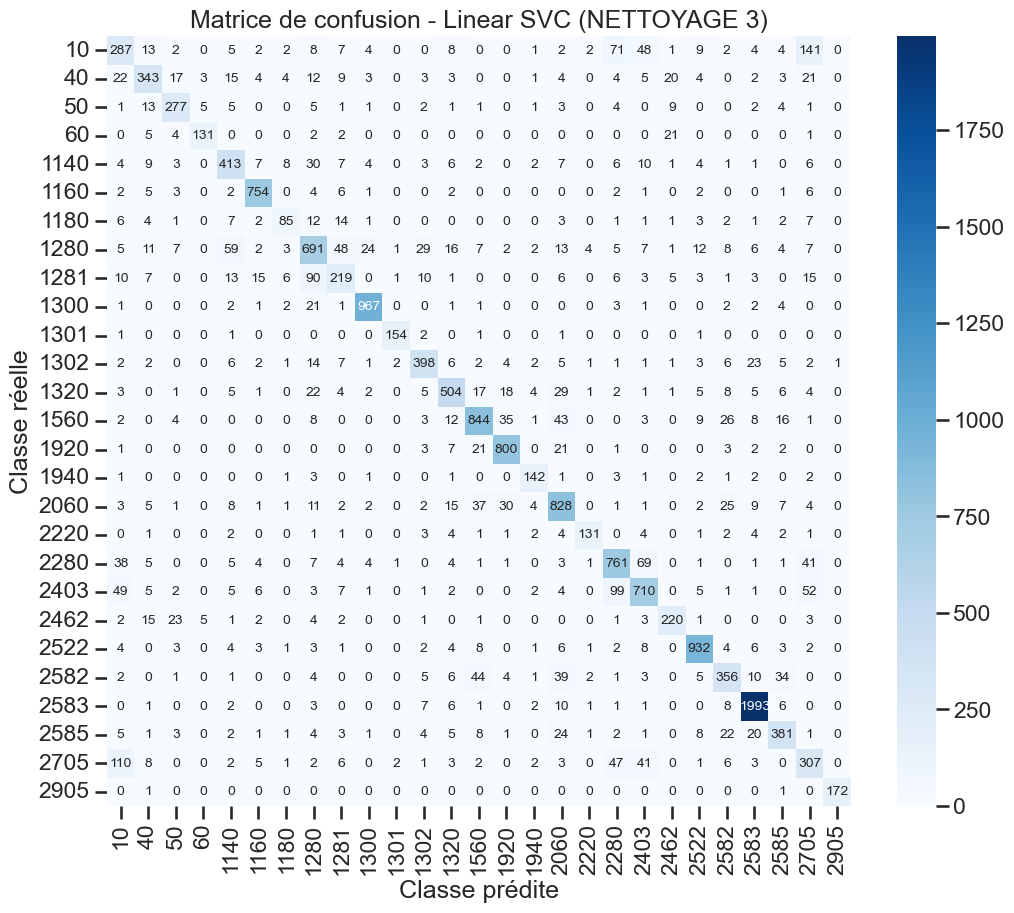

In [45]:
# -------------------------------
# NETTOYAGE 3: lettres minuscules + chiffres + espaces uniquement
# -------------------------------
# 4.2 Linear SVM
# -------------------------------
# Afficher Heatmap de la matrice de confusion

cm = pd.crosstab(y_test, y_pred_svc_3, rownames=['Réel'], colnames=['Prédit'])

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", annot_kws={"size": 10})
plt.title("Matrice de confusion - Linear SVC (NETTOYAGE 3)")
plt.ylabel("Classe réelle")
plt.xlabel("Classe prédite")
plt.show()


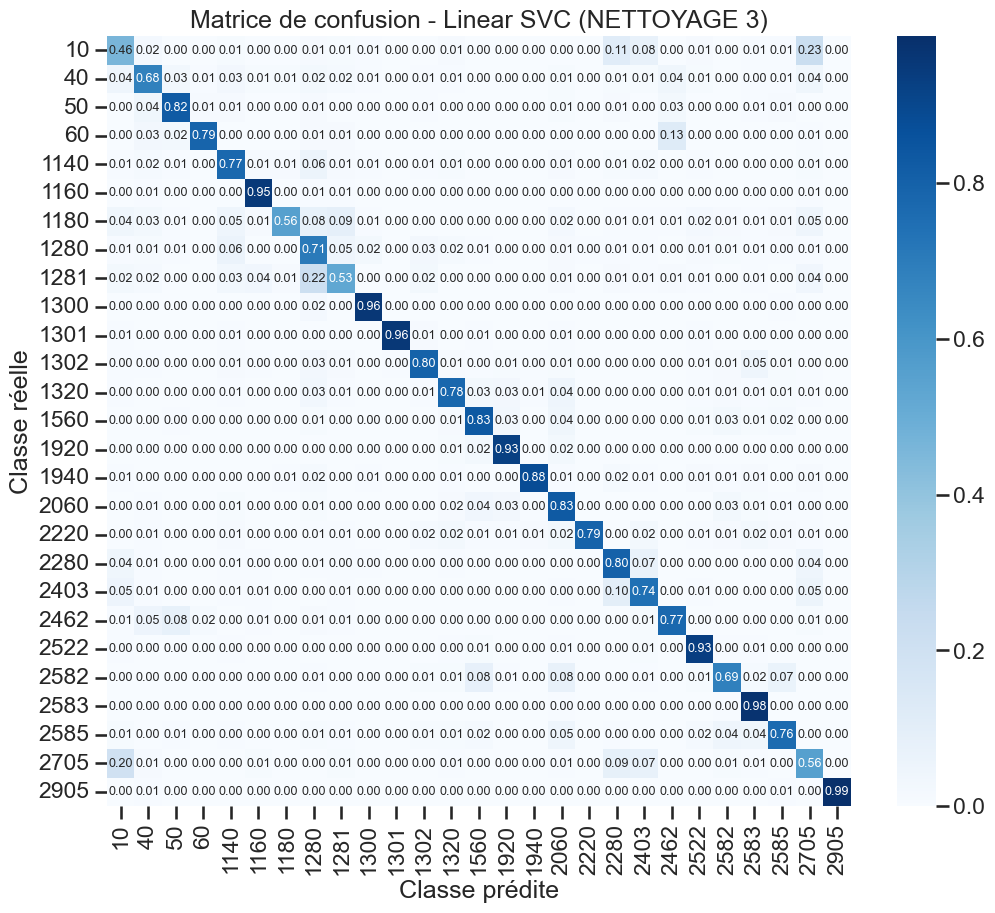

In [46]:
# -------------------------------
# NETTOYAGE 3: lettres minuscules + chiffres + espaces uniquement
# -------------------------------
# 4.2 Linear SVM
# -------------------------------
# Afficher Heatmap de la matrice de confusion (en proportion)

cm = confusion_matrix(y_test, y_pred_svc_3, normalize='true')

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='.2f', cmap="Blues", annot_kws={"size": 9},
            xticklabels=sorted(essai4["prdtypecode"].unique()), 
            yticklabels=sorted(essai4["prdtypecode"].unique()))

plt.title("Matrice de confusion - Linear SVC (NETTOYAGE 3)")
plt.ylabel("Classe réelle")
plt.xlabel("Classe prédite")
plt.show()

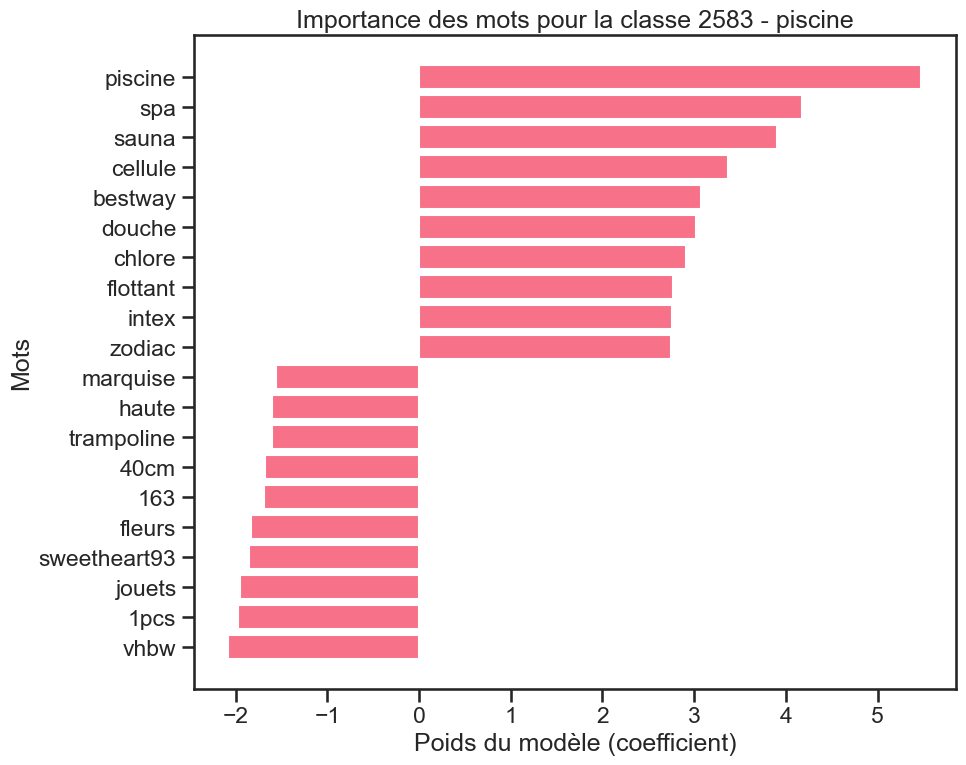

In [47]:
# -------------------------------
# NETTOYAGE 3: lettres minuscules + chiffres + espaces uniquement
# -------------------------------
# 4.2 Linear SVM
# -------------------------------
# Interpretabilité du modèle: Importance (coefficient) des mots dans chaque classe
# -------------------------------
# Récupérer les informations du modèle
# ---------------------------
feature_names = tfidf_3.get_feature_names_out()
classes = svc_3.classes_
coefs = svc_3.coef_

# ---------------------------
# Fonction pour extraire top mots positifs et négatifs 
# ---------------------------
def top_features_for_class(class_index, top_n=20):

    coef = coefs[class_index]

    # Mots positifs
    top_pos_idx = np.argsort(coef)[-top_n:]
    top_pos_words = [(feature_names[i], coef[i]) for i in top_pos_idx[::-1]]

    # Mots négatifs
    top_neg_idx = np.argsort(coef)[:top_n]
    top_neg_words = [(feature_names[i], coef[i]) for i in top_neg_idx]

    return top_pos_words, top_neg_words

# ---------------------------
# Construire df_interpretation
# ---------------------------
rows = []

for idx, cls in enumerate(classes):
    top_pos, top_neg = top_features_for_class(idx, top_n=15)

    for word, weight in top_pos:
        rows.append([cls, word, weight, "positif"])

    for word, weight in top_neg:
        rows.append([cls, word, weight, "negatif"])

df_interpretation = pd.DataFrame(rows, columns=["classe", "mot", "poids", "type"])

# ---------------------------
# Filtrer la classe 2583
# ---------------------------
df_class = df_interpretation[df_interpretation["classe"] == 2583]

top_pos = df_class[df_class["type"] == "positif"].sort_values("poids", ascending=False).head(10)
top_neg = df_class[df_class["type"] == "negatif"].sort_values("poids").head(10)

# ---------------------------
# Tri global pour affichage du plus négatif au plus positif
# ---------------------------
plot_df = pd.concat([top_pos, top_neg]).sort_values("poids")

# ---------------------------
# Graphe
# ---------------------------
plt.figure(figsize=(10, 8))
plt.barh(plot_df["mot"], plot_df["poids"])
plt.xlabel("Poids du modèle (coefficient)")
plt.ylabel("Mots")
plt.title("Importance des mots pour la classe 2583 - piscine")
plt.tight_layout()
plt.show()

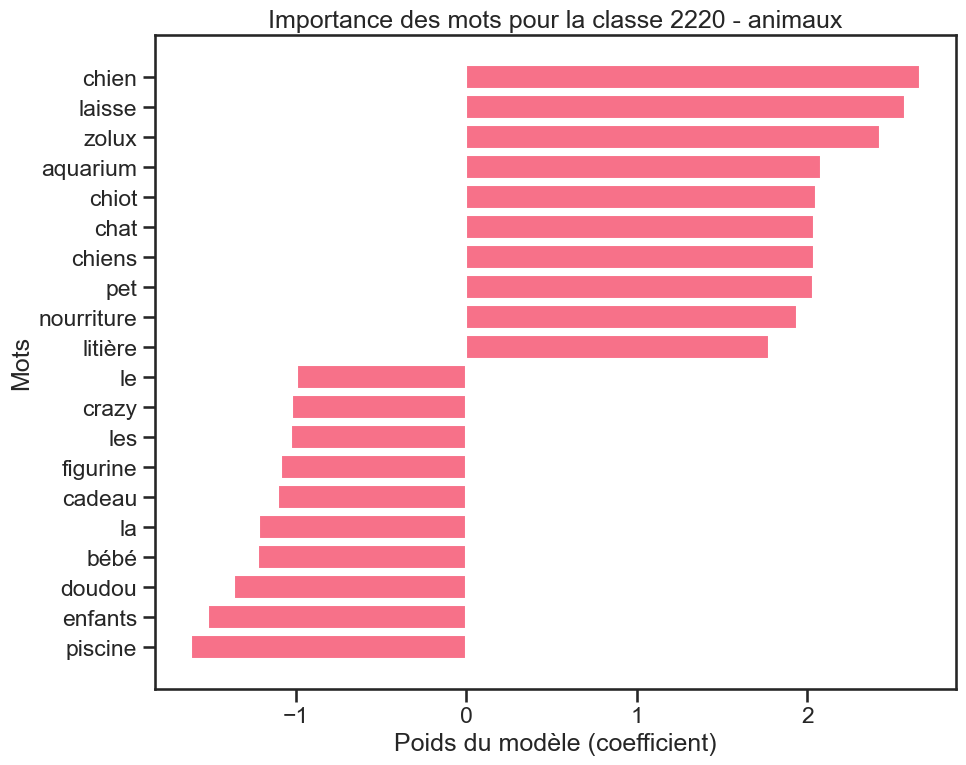

In [49]:
# -------------------------------
# NETTOYAGE 3: lettres minuscules + chiffres + espaces uniquement
# -------------------------------
# 4.2 Linear SVM
# -------------------------------
# Interpretabilité du modèle: Importance (coefficient) des mots dans chaque classe (suite)
# -------------------------------
# Filtrer la classe 2220 - animaux
# ---------------------------
df_class = df_interpretation[df_interpretation["classe"] == 2220]

top_pos = df_class[df_class["type"] == "positif"].sort_values("poids", ascending=False).head(10)
top_neg = df_class[df_class["type"] == "negatif"].sort_values("poids").head(10)

# ---------------------------
# Tri global pour affichage du plus négatif au plus positif
# ---------------------------
plot_df = pd.concat([top_pos, top_neg]).sort_values("poids")

# ---------------------------
# Graphe
# ---------------------------
plt.figure(figsize=(10, 8))
plt.barh(plot_df["mot"], plot_df["poids"])
plt.xlabel("Poids du modèle (coefficient)")
plt.ylabel("Mots")
plt.title("Importance des mots pour la classe 2220 - animaux")
plt.tight_layout()
plt.show()

In [99]:
# -------------------------------
# NETTOYAGE 3: lettres minuscules + chiffres + espaces uniquement
# -------------------------------
# 4.2 Linear SVM
# -------------------------------
# Sauvegarde du vectorizer
joblib.dump(tfidf_3, "ML_text4_tfidf_3.joblib")

# Sauvegarde du modèle Linear SVC
joblib.dump(svc_3, "ML_text4_svc_3.joblib")

print("Modèle et vectorizer sauvegardés avec succès.")


Modèle et vectorizer sauvegardés avec succès.


In [100]:
# -------------------------------
# NETTOYAGE 3: lettres minuscules + chiffres + espaces uniquement
# -------------------------------
# 4.2 Linear SVM
# -------------------------------
# Chargement du vectorizer
essai_tfidf_3 = joblib.load("ML_text4_tfidf_3.joblib")

# Chargement du modèle Linear SVC
essai_svc_3 = joblib.load("ML_text4_svc_3.joblib")

print("Modèle et vectorizer chargés.")


Modèle et vectorizer chargés.


In [108]:
# -------------------------------
# NETTOYAGE 3: lettres minuscules + chiffres + espaces uniquement
# -------------------------------
# 4.2 Linear SVM
# -------------------------------
# Exemple de prédiction après rechargement
nouveau_texte = ["piscine"]
X_new = essai_tfidf_3.transform(nouveau_texte)
prediction = essai_svc_3.predict(X_new)
print("Prediction :", prediction[0])

nouveau_texte_2 = ["chien et chat dans la piscine"]
X_new_2 = essai_tfidf_3.transform(nouveau_texte_2)
prediction_2 = essai_svc_3.predict(X_new_2)
print("Prediction 2:", prediction_2[0])

nouveau_texte_3 = ["piscine en chocolat bio"]
X_new_3 = essai_tfidf_3.transform(nouveau_texte_3)
prediction_3 = essai_svc_3.predict(X_new_3)
print("Prediction 3:", prediction_3[0])

Prediction : 2583
Prediction 2: 2220
Prediction 3: 1940


In [107]:
# -------------------------------
# NETTOYAGE 3: lettres minuscules + chiffres + espaces uniquement
# -------------------------------
# 4.2 Linear SVM
# -------------------------------
# prédiction après rechargement
X_test_tfidf_3_essai = essai_tfidf_3.transform(X_test_text_3)
y_pred_svc_3_essai = essai_svc_3.predict(X_test_tfidf_3_essai)
print("F1-score Linear SVC (SVM) essai après chargement: ", f1_score(y_test, y_pred_svc_3_essai, average="weighted"))

F1-score Linear SVC (SVM) essai après chargement:  0.811219343697387


In [66]:
# -------------------------------
# NETTOYAGE 4 : lettres minuscules + chiffres + espaces uniquement + suppression des stopwords
# -------------------------------
# Téléchargement des stopwords français 
# nltk.download('stopwords', quiet=True)
french_stopwords = set(stopwords.words('french'))

def clean_letters_digits_stopword_fr(text):
    """
    Nettoyage niveau 4 :
    - met tout en minuscules
    - garde uniquement les lettres (accentuées incluses), chiffres et espaces
    - supprime les autres caractères spéciaux (ponctuations, symboles, emojis…)
    - supprime les stopwords français
    """
    # Minuscules
    text = text.lower()
    # Conserve lettres accentuées (latin étendu), chiffres et espaces
    text = re.sub(r"[^a-zA-ZÀ-ÿ0-9\s]", " ", text)
    # Supprime les espaces multiples
    text = re.sub(r"\s+", " ", text).strip()
    # Supprime les stopwords français
    words = [word for word in text.split() if word not in french_stopwords]
    text = " ".join(words)
    return text


In [67]:
# -------------------------------
# NETTOYAGE 4: lettres minuscules + chiffres + stopword fr
# -------------------------------
essai4["designation_clean4"] = essai4["designation"].apply(clean_letters_digits_stopword_fr)
essai4.head(2)

,prdtypecode,designation,description,productid,imageid,designation_clean1,designation_clean2,designation_clean3,designation_clean4
0,10,Olivia: Personalisiertes Notizbuch / 150 Seite...,NaN,3804725264,1263597046,olivia: personalisiertes notizbuch / 150 seite...,olivia personalisiertes notizbuch seiten punkt...,olivia personalisiertes notizbuch 150 seiten p...,olivia personalisiertes notizbuch 150 seiten p...
1,2280,Journal Des Arts (Le) N° 133 Du 28/09/2001 - L...,NaN,436067568,1008141237,journal des arts (le) n° 133 du 28/09/2001 - l...,journal des arts le n du l art et son marche s...,journal des arts le n 133 du 28 09 2001 l art ...,journal arts 133 28 09 2001 art marche salon a...


In [68]:
# -------------------------------
# NETTOYAGE 4: lettres minuscules + chiffres + stopword fr
# -------------------------------
# Refaire la séparation X et y
X_text_4 = essai4["designation_clean4"]
y = essai4["prdtypecode"]
X_train_text_4, X_test_text_4, y_train, y_test = train_test_split(X_text_4, y, test_size=0.2, stratify=y, random_state=42)

In [69]:
# -------------------------------
# NETTOYAGE 4: lettres minuscules + chiffres + stopword fr
# -------------------------------
# Refaire Etape 3: Représentation du texte
tfidf_4 = TfidfVectorizer(max_features=20000)
X_train_tfidf_4 = tfidf_4.fit_transform(X_train_text_4)
X_test_tfidf_4 = tfidf_4.transform(X_test_text_4)

In [70]:
# -------------------------------
# NETTOYAGE 4: lettres minuscules + chiffres + stopword fr
# -------------------------------
# Refaire Étape 4 — Modèles classiques à tester
# 4.1 Logistic Regression (multiclasse)
lr_4 = LogisticRegression(max_iter=1000)
lr_4.fit(X_train_tfidf_4, y_train)
y_pred_lr_4 = lr_4.predict(X_test_tfidf_4)

In [71]:
# -------------------------------
# NETTOYAGE 4: lettres minuscules + chiffres + stopword fr
# -------------------------------
# 4.1 Logistic Regression (multiclasse)
print("F1-score LogisticRegression: ", f1_score(y_test, y_pred_lr_4, average="weighted"))
print("Rapport Classification LogisticRegression - NETTOYAGE 4: lettres minuscules + chiffres + stopword fr:") 
print(classification_report_imbalanced(y_test, y_pred_lr_4))
print("Matrice confusion LogisticRegression - NETTOYAGE 4: lettres minuscules + chiffres + stopword fr:")
display(pd.crosstab(y_test, y_pred_lr_4, rownames=['Reel'], colnames=['Predit']))

F1-score LogisticRegression:  0.7968806185289949
Rapport Classification LogisticRegression - NETTOYAGE 4: lettres minuscules + chiffres + stopword fr:
                   pre       rec       spe        f1       geo       iba       sup

         10       0.47      0.49      0.98      0.48      0.70      0.46       623
         40       0.75      0.65      0.99      0.70      0.80      0.62       502
         50       0.79      0.76      1.00      0.78      0.87      0.74       336
         60       0.91      0.71      1.00      0.80      0.84      0.69       166
       1140       0.79      0.77      0.99      0.78      0.88      0.75       534
       1160       0.91      0.93      1.00      0.92      0.96      0.92       791
       1180       0.77      0.44      1.00      0.56      0.67      0.42       153
       1280       0.69      0.74      0.98      0.72      0.85      0.71       974
       1281       0.70      0.44      1.00      0.54      0.66      0.41       414
       1300       

Predit,10,40,50,60,1140,1160,1180,1280,1281,1300,...,2220,2280,2403,2462,2522,2582,2583,2585,2705,2905
Reel,,,,,,,,,,,,,,,,,,,,,
10,308,5,0,0,2,0,0,8,0,1,...,1,74,54,1,6,0,3,1,152,0
40,46,325,19,3,10,5,1,13,7,0,...,0,11,7,13,2,1,1,2,25,0
50,4,15,257,6,5,2,0,9,0,2,...,0,5,0,13,1,0,4,2,1,0
60,0,13,12,118,0,0,0,3,2,0,...,0,0,0,17,0,0,0,0,0,0
1140,8,10,4,0,412,10,7,31,3,0,...,0,10,10,1,5,1,2,2,9,0
1160,8,2,1,0,4,738,0,2,4,3,...,1,7,5,0,2,0,0,0,14,0
1180,14,1,1,0,9,4,68,12,12,1,...,0,2,4,1,4,3,0,0,12,0
1280,12,13,2,0,42,5,1,725,29,21,...,4,7,5,1,9,6,9,4,12,0
1281,19,9,0,0,14,20,7,98,182,0,...,2,6,5,5,5,1,5,0,15,0


In [72]:
# -------------------------------
# NETTOYAGE 4: lettres minuscules + chiffres + stopword fr
# -------------------------------
# 4.2 Linear SVM
svc_4 = LinearSVC()
svc_4.fit(X_train_tfidf_4, y_train)
y_pred_svc_4 = svc_4.predict(X_test_tfidf_4)

In [73]:
# -------------------------------
# NETTOYAGE 4: lettres minuscules + chiffres + stopword fr
# -------------------------------
# 4.2 Linear SVM
print("F1-score Linear SVC (SVM): ", f1_score(y_test, y_pred_svc_4, average="weighted"))
print("Rapport Classification Linear SVC (SVM)- NETTOYAGE 4: lettres minuscules + chiffres + stopword fr:")
print(classification_report_imbalanced(y_test, y_pred_svc_4))
print("Matrice confusion Linear SVC (SVM) - NETTOYAGE 4: lettres minuscules + chiffres + stopword fr:",
display(pd.crosstab(y_test, y_pred_svc_4, rownames=['Reel'], colnames=['Predit'])))

F1-score Linear SVC (SVM):  0.807468270943066
Rapport Classification Linear SVC (SVM)- NETTOYAGE 4: lettres minuscules + chiffres + stopword fr:
                   pre       rec       spe        f1       geo       iba       sup

         10       0.50      0.47      0.98      0.49      0.68      0.44       623
         40       0.75      0.69      0.99      0.72      0.82      0.66       502
         50       0.79      0.80      1.00      0.80      0.89      0.78       336
         60       0.89      0.81      1.00      0.85      0.90      0.80       166
       1140       0.74      0.78      0.99      0.76      0.88      0.75       534
       1160       0.93      0.95      1.00      0.94      0.97      0.94       791
       1180       0.73      0.58      1.00      0.64      0.76      0.55       153
       1280       0.72      0.71      0.98      0.71      0.84      0.68       974
       1281       0.63      0.52      0.99      0.57      0.72      0.49       414
       1300       0.95  

Predit,10,40,50,60,1140,1160,1180,1280,1281,1300,...,2220,2280,2403,2462,2522,2582,2583,2585,2705,2905
Reel,,,,,,,,,,,,,,,,,,,,,
10,293,16,1,0,5,1,2,5,4,4,...,4,60,54,2,9,3,4,5,138,0
40,24,344,14,5,18,5,3,12,9,3,...,1,5,6,19,3,0,2,2,15,0
50,2,12,270,5,5,0,0,5,2,1,...,0,5,0,14,1,0,2,3,1,0
60,0,5,4,135,0,0,0,2,2,0,...,0,0,0,18,0,0,0,0,0,0
1140,6,9,4,0,414,7,8,33,8,4,...,0,6,9,1,4,0,2,0,3,0
1160,3,4,3,0,2,753,0,4,6,1,...,0,1,1,0,2,0,0,1,8,0
1180,7,4,0,0,7,1,88,11,12,1,...,0,1,1,1,3,2,1,0,9,0
1280,7,9,6,0,58,2,3,692,46,26,...,4,7,5,1,13,7,7,3,7,0
1281,11,8,0,0,12,17,6,89,214,0,...,2,4,4,6,3,1,3,0,14,0


Matrice confusion Linear SVC (SVM) - NETTOYAGE 4: lettres minuscules + chiffres + stopword fr: None


In [74]:
# -------------------------------
# NETTOYAGE 5 : lettres minuscules + chiffres + suppression des stopwords FR + EN
# -------------------------------

# Ensemble combiné de stopwords français et anglais
french_stopwords = set(stopwords.words('french'))
english_stopwords = set(stopwords.words('english'))
combined_stopwords = french_stopwords.union(english_stopwords)

def clean_letters_digits_stopwords_fr_en(text):
    """
    Nettoyage niveau 5 :
    - met tout en minuscules
    - garde uniquement les lettres (accentuées incluses), chiffres et espaces
    - supprime les caractères spéciaux (ponctuations, symboles, emojis…)
    - supprime les stopwords français et anglais
    """
    # Minuscules
    text = text.lower()
    # Conserve lettres accentuées (latin étendu), chiffres et espaces
    text = re.sub(r"[^a-zA-ZÀ-ÿ0-9\s]", " ", text)
    # Supprime les espaces multiples
    text = re.sub(r"\s+", " ", text).strip()
    # Supprime les stopwords français et anglais
    words = [word for word in text.split() if word not in combined_stopwords]
    text = " ".join(words)
    return text


In [75]:
# -------------------------------
# NETTOYAGE 5 : lettres minuscules + chiffres + suppression des stopwords FR + EN
# -------------------------------
essai4["designation_clean5"] = essai4["designation"].apply(clean_letters_digits_stopwords_fr_en)
essai4.head(2)

,prdtypecode,designation,description,productid,imageid,designation_clean1,designation_clean2,designation_clean3,designation_clean4,designation_clean5
0,10,Olivia: Personalisiertes Notizbuch / 150 Seite...,NaN,3804725264,1263597046,olivia: personalisiertes notizbuch / 150 seite...,olivia personalisiertes notizbuch seiten punkt...,olivia personalisiertes notizbuch 150 seiten p...,olivia personalisiertes notizbuch 150 seiten p...,olivia personalisiertes notizbuch 150 seiten p...
1,2280,Journal Des Arts (Le) N° 133 Du 28/09/2001 - L...,NaN,436067568,1008141237,journal des arts (le) n° 133 du 28/09/2001 - l...,journal des arts le n du l art et son marche s...,journal des arts le n 133 du 28 09 2001 l art ...,journal arts 133 28 09 2001 art marche salon a...,journal arts 133 28 09 2001 art marche salon a...


In [76]:
# -------------------------------
# NETTOYAGE 5 : lettres minuscules + chiffres + suppression des stopwords FR + EN
# -------------------------------
# Refaire la séparation X et y
X_text_5 = essai4["designation_clean5"]
y = essai4["prdtypecode"]
X_train_text_5, X_test_text_5, y_train, y_test = train_test_split(X_text_5, y, test_size=0.2, stratify=y, random_state=42)

In [77]:
# -------------------------------
# NETTOYAGE 5 : lettres minuscules + chiffres + suppression des stopwords FR + EN
# -------------------------------
# Refaire Etape 3: Représentation du texte
tfidf_5 = TfidfVectorizer(max_features=20000)
X_train_tfidf_5 = tfidf_5.fit_transform(X_train_text_5)
X_test_tfidf_5 = tfidf_5.transform(X_test_text_5)

In [78]:
# -------------------------------
# NETTOYAGE 5 : lettres minuscules + chiffres + suppression des stopwords FR + EN
# -------------------------------
# Refaire Étape 4 — Modèles classiques à tester
# 4.1 Logistic Regression (multiclasse)
lr_5 = LogisticRegression(max_iter=1000)
lr_5.fit(X_train_tfidf_5, y_train)
y_pred_lr_5 = lr_5.predict(X_test_tfidf_5)

In [79]:
# -------------------------------
# NETTOYAGE 5 : lettres minuscules + chiffres + suppression des stopwords FR + EN
# -------------------------------
# 4.1 Logistic Regression (multiclasse)
print("F1-score LogisticRegression: ", f1_score(y_test, y_pred_lr_5, average="weighted"))
print("Rapport Classification LogisticRegression - NETTOYAGE 5 : lettres minuscules + chiffres + suppression des stopwords FR + EN:") 
print(classification_report_imbalanced(y_test, y_pred_lr_5))
print("Matrice confusion LogisticRegression - NETTOYAGE 5 : lettres minuscules + chiffres + suppression des stopwords FR + EN:")
display(pd.crosstab(y_test, y_pred_lr_5, rownames=['Reel'], colnames=['Predit']))

F1-score LogisticRegression:  0.7935820075734341
Rapport Classification LogisticRegression - NETTOYAGE 5 : lettres minuscules + chiffres + suppression des stopwords FR + EN:
                   pre       rec       spe        f1       geo       iba       sup

         10       0.38      0.52      0.97      0.44      0.71      0.48       623
         40       0.75      0.64      0.99      0.69      0.80      0.62       502
         50       0.79      0.77      1.00      0.78      0.88      0.75       336
         60       0.89      0.70      1.00      0.78      0.84      0.68       166
       1140       0.78      0.76      0.99      0.77      0.87      0.74       534
       1160       0.91      0.93      1.00      0.92      0.96      0.92       791
       1180       0.76      0.44      1.00      0.56      0.67      0.42       153
       1280       0.69      0.74      0.98      0.72      0.85      0.71       974
       1281       0.69      0.44      0.99      0.54      0.66      0.41      

Predit,10,40,50,60,1140,1160,1180,1280,1281,1300,...,2220,2280,2403,2462,2522,2582,2583,2585,2705,2905
Reel,,,,,,,,,,,,,,,,,,,,,
10,322,6,0,1,2,1,1,9,0,3,...,1,70,56,1,7,0,3,1,129,0
40,54,323,19,3,9,5,1,13,8,0,...,0,9,5,15,2,1,1,2,18,0
50,5,15,259,6,5,1,0,9,1,1,...,0,4,0,12,1,0,4,2,1,0
60,1,14,12,116,1,0,0,2,2,0,...,0,0,0,18,0,0,0,0,0,0
1140,12,10,4,0,408,7,7,34,4,0,...,0,9,10,1,5,1,2,1,8,0
1160,19,2,1,0,4,735,0,2,4,2,...,1,8,4,0,2,0,0,0,7,0
1180,20,1,1,0,9,6,68,11,12,1,...,0,2,4,1,4,3,0,0,5,0
1280,22,10,2,0,44,6,1,724,29,21,...,5,6,6,1,9,5,9,3,5,0
1281,25,9,0,0,14,20,7,96,182,0,...,2,7,3,5,5,1,5,0,12,0


In [80]:
# -------------------------------
# NETTOYAGE 5 : lettres minuscules + chiffres + suppression des stopwords FR + EN
# -------------------------------
# 4.2 Linear SVM
svc_5 = LinearSVC()
svc_5.fit(X_train_tfidf_5, y_train)
y_pred_svc_5 = svc_5.predict(X_test_tfidf_5)

In [81]:
# -------------------------------
# NETTOYAGE 5 : lettres minuscules + chiffres + suppression des stopwords FR + EN
# -------------------------------
# 4.2 Linear SVM
print("F1-score Linear SVC (SVM): ", f1_score(y_test, y_pred_svc_5, average="weighted"))
print("Rapport Classification Linear SVC (SVM)- NETTOYAGE 5 : lettres minuscules + chiffres + suppression des stopwords FR + EN:")
print(classification_report_imbalanced(y_test, y_pred_svc_5))
print("Matrice confusion Linear SVC (SVM) - NETTOYAGE 5 : lettres minuscules + chiffres + suppression des stopwords FR + EN:",
display(pd.crosstab(y_test, y_pred_svc_5, rownames=['Reel'], colnames=['Predit'])))

F1-score Linear SVC (SVM):  0.8060866666999148
Rapport Classification Linear SVC (SVM)- NETTOYAGE 5 : lettres minuscules + chiffres + suppression des stopwords FR + EN:
                   pre       rec       spe        f1       geo       iba       sup

         10       0.47      0.44      0.98      0.45      0.65      0.40       623
         40       0.74      0.68      0.99      0.71      0.82      0.65       502
         50       0.79      0.80      1.00      0.80      0.89      0.78       336
         60       0.89      0.80      1.00      0.84      0.89      0.78       166
       1140       0.75      0.78      0.99      0.77      0.88      0.76       534
       1160       0.93      0.95      1.00      0.94      0.97      0.94       791
       1180       0.74      0.59      1.00      0.66      0.77      0.57       153
       1280       0.72      0.72      0.98      0.72      0.84      0.68       974
       1281       0.63      0.50      0.99      0.56      0.71      0.48       414


Predit,10,40,50,60,1140,1160,1180,1280,1281,1300,...,2220,2280,2403,2462,2522,2582,2583,2585,2705,2905
Reel,,,,,,,,,,,,,,,,,,,,,
10,272,18,0,1,5,3,2,8,5,3,...,4,64,58,2,8,3,4,5,141,0
40,24,340,15,6,16,4,4,13,11,1,...,1,6,6,19,2,0,1,2,17,0
50,3,13,270,4,5,0,0,5,2,1,...,0,5,0,14,1,0,2,4,0,0
60,1,5,5,133,0,0,0,2,2,0,...,0,0,0,18,0,0,0,0,0,0
1140,4,10,3,0,419,8,8,31,6,4,...,0,6,9,1,4,0,2,0,2,0
1160,6,4,2,0,2,751,0,4,6,0,...,0,4,1,0,2,0,0,0,7,0
1180,4,5,0,0,8,2,91,10,11,1,...,0,2,1,1,3,2,1,0,9,0
1280,11,9,6,0,55,3,3,697,44,25,...,4,7,5,0,12,7,6,2,8,0
1281,12,8,0,0,11,17,6,89,209,0,...,2,4,6,6,3,1,3,0,16,0


Matrice confusion Linear SVC (SVM) - NETTOYAGE 5 : lettres minuscules + chiffres + suppression des stopwords FR + EN: None


In [82]:
# -------------------------------
# NETTOYAGE 6 : lettres minuscules + chiffres + suppression des stopwords FR + EN + DE
# -------------------------------

# Ensemble combiné de stopwords français, anglais et allemands
french_stopwords = set(stopwords.words('french'))
english_stopwords = set(stopwords.words('english'))
german_stopwords = set(stopwords.words('german'))
combined_stopwords = french_stopwords.union(english_stopwords, german_stopwords)

def clean_letters_digits_stopwords_fr_en_de(text):
    """
    Nettoyage niveau 5 :
    - met tout en minuscules
    - garde uniquement les lettres (accentuées incluses), chiffres et espaces
    - supprime les caractères spéciaux (ponctuations, symboles, emojis…)
    - supprime les stopwords français, anglais et allemands
    """
    # Minuscules
    text = text.lower()
    # Conserve lettres accentuées (latin étendu), chiffres et espaces
    text = re.sub(r"[^a-zA-ZÀ-ÿ0-9\s]", " ", text)
    # Supprime les espaces multiples
    text = re.sub(r"\s+", " ", text).strip()
    # Supprime les stopwords FR + EN + DE
    words = [word for word in text.split() if word not in combined_stopwords]
    text = " ".join(words)
    return text


In [83]:
# -------------------------------
# NETTOYAGE 6 : lettres minuscules + chiffres + suppression des stopwords FR + EN + DE
# -------------------------------
essai4["designation_clean6"] = essai4["designation"].apply(clean_letters_digits_stopwords_fr_en_de)
essai4.head(2)

,prdtypecode,designation,description,productid,imageid,designation_clean1,designation_clean2,designation_clean3,designation_clean4,designation_clean5,designation_clean6
0,10,Olivia: Personalisiertes Notizbuch / 150 Seite...,NaN,3804725264,1263597046,olivia: personalisiertes notizbuch / 150 seite...,olivia personalisiertes notizbuch seiten punkt...,olivia personalisiertes notizbuch 150 seiten p...,olivia personalisiertes notizbuch 150 seiten p...,olivia personalisiertes notizbuch 150 seiten p...,olivia personalisiertes notizbuch 150 seiten p...
1,2280,Journal Des Arts (Le) N° 133 Du 28/09/2001 - L...,NaN,436067568,1008141237,journal des arts (le) n° 133 du 28/09/2001 - l...,journal des arts le n du l art et son marche s...,journal des arts le n 133 du 28 09 2001 l art ...,journal arts 133 28 09 2001 art marche salon a...,journal arts 133 28 09 2001 art marche salon a...,journal arts 133 28 09 2001 art marche salon a...


In [90]:
# -------------------------------
# NETTOYAGE 6 : lettres minuscules + chiffres + suppression des stopwords FR + EN + DE
# -------------------------------
# Sauvegarder le dataframe essai4 en Rakuten_text_clean.csv
essai4.to_csv("Rakuten_text_clean.csv", index=False)


In [92]:
# -------------------------------
# NETTOYAGE 6 : lettres minuscules + chiffres + suppression des stopwords FR + EN + DE
# -------------------------------
# lire le fichier Rakuten_text_clean.csv
essai_TDP = pd.read_csv("Rakuten_text_clean.csv")
essai_TDP.head(2)

,prdtypecode,designation,description,productid,imageid,designation_clean1,designation_clean2,designation_clean3,designation_clean4,designation_clean5,designation_clean6
0,10,Olivia: Personalisiertes Notizbuch / 150 Seite...,NaN,3804725264,1263597046,olivia: personalisiertes notizbuch / 150 seite...,olivia personalisiertes notizbuch seiten punkt...,olivia personalisiertes notizbuch 150 seiten p...,olivia personalisiertes notizbuch 150 seiten p...,olivia personalisiertes notizbuch 150 seiten p...,olivia personalisiertes notizbuch 150 seiten p...
1,2280,Journal Des Arts (Le) N° 133 Du 28/09/2001 - L...,NaN,436067568,1008141237,journal des arts (le) n° 133 du 28/09/2001 - l...,journal des arts le n du l art et son marche s...,journal des arts le n 133 du 28 09 2001 l art ...,journal arts 133 28 09 2001 art marche salon a...,journal arts 133 28 09 2001 art marche salon a...,journal arts 133 28 09 2001 art marche salon a...


In [94]:
# -------------------------------
# NETTOYAGE 6 : lettres minuscules + chiffres + suppression des stopwords FR + EN + DE
# -------------------------------
# Sauvegarder 10 lignes du dataframe essai4 en Rakuten_text_clean_2lines.csv
essai4.head(10).to_csv("Rakuten_text_clean_10lines.csv", index=False)

In [96]:
# -------------------------------
# NETTOYAGE 6 : lettres minuscules + chiffres + suppression des stopwords FR + EN + DE
# -------------------------------
# lire le fichier Rakuten_text_clean_10lines.csv
essai_TDP_2 = pd.read_csv("Rakuten_text_clean_10lines.csv")
essai_TDP_2.head(3)

,prdtypecode,designation,description,productid,imageid,designation_clean1,designation_clean2,designation_clean3,designation_clean4,designation_clean5,designation_clean6
0,10,Olivia: Personalisiertes Notizbuch / 150 Seite...,NaN,3804725264,1263597046,olivia: personalisiertes notizbuch / 150 seite...,olivia personalisiertes notizbuch seiten punkt...,olivia personalisiertes notizbuch 150 seiten p...,olivia personalisiertes notizbuch 150 seiten p...,olivia personalisiertes notizbuch 150 seiten p...,olivia personalisiertes notizbuch 150 seiten p...
1,2280,Journal Des Arts (Le) N° 133 Du 28/09/2001 - L...,NaN,436067568,1008141237,journal des arts (le) n° 133 du 28/09/2001 - l...,journal des arts le n du l art et son marche s...,journal des arts le n 133 du 28 09 2001 l art ...,journal arts 133 28 09 2001 art marche salon a...,journal arts 133 28 09 2001 art marche salon a...,journal arts 133 28 09 2001 art marche salon a...
2,50,Grand Stylet Ergonomique Bleu Gamepad Nintendo...,PILOT STYLE Touch Pen de marque Speedlink est ...,201115110,938777978,grand stylet ergonomique bleu gamepad nintendo...,grand stylet ergonomique bleu gamepad nintendo...,grand stylet ergonomique bleu gamepad nintendo...,grand stylet ergonomique bleu gamepad nintendo...,grand stylet ergonomique bleu gamepad nintendo...,grand stylet ergonomique bleu gamepad nintendo...


In [123]:
# -------------------------------
# NETTOYAGE 6 : lettres minuscules + chiffres + suppression des stopwords FR + EN + DE
# -------------------------------
# Afficher les colonnes designation, designation_cleanX, ...
essai_TDP_2_selected = essai_TDP_2.iloc[:, [1, 6, 7, 8]]
display(essai_TDP_2_selected.head(2))


,designation,designation_clean2,designation_clean3,designation_clean4
0,Olivia: Personalisiertes Notizbuch / 150 Seite...,olivia personalisiertes notizbuch seiten punkt...,olivia personalisiertes notizbuch 150 seiten p...,olivia personalisiertes notizbuch 150 seiten p...
1,Journal Des Arts (Le) N° 133 Du 28/09/2001 - L...,journal des arts le n du l art et son marche s...,journal des arts le n 133 du 28 09 2001 l art ...,journal arts 133 28 09 2001 art marche salon a...


In [84]:
# -------------------------------
# NETTOYAGE 6 : lettres minuscules + chiffres + suppression des stopwords FR + EN + DE
# -------------------------------
# Refaire la séparation X et y
X_text_6 = essai4["designation_clean6"]
y = essai4["prdtypecode"]
X_train_text_6, X_test_text_6, y_train, y_test = train_test_split(X_text_6, y, test_size=0.2, stratify=y, random_state=42)

In [85]:
# -------------------------------
# NETTOYAGE 6 : lettres minuscules + chiffres + suppression des stopwords FR + EN + DE
# -------------------------------
# Refaire Etape 3: Représentation du texte
tfidf_6 = TfidfVectorizer(max_features=20000)
X_train_tfidf_6 = tfidf_6.fit_transform(X_train_text_6)
X_test_tfidf_6 = tfidf_6.transform(X_test_text_6)

In [86]:
# -------------------------------
# NETTOYAGE 6 : lettres minuscules + chiffres + suppression des stopwords FR + EN + DE
# -------------------------------
# Refaire Étape 4 — Modèles classiques à tester
# 4.1 Logistic Regression (multiclasse)
lr_6 = LogisticRegression(max_iter=1000)
lr_6.fit(X_train_tfidf_6, y_train)
y_pred_lr_6 = lr_6.predict(X_test_tfidf_6)

In [87]:
# -------------------------------
# NETTOYAGE 6 : lettres minuscules + chiffres + suppression des stopwords FR + EN + DE
# -------------------------------
# 4.1 Logistic Regression (multiclasse)
print("F1-score LogisticRegression: ", f1_score(y_test, y_pred_lr_6, average="weighted"))
print("Rapport Classification LogisticRegression - NETTOYAGE 6 : lettres minuscules + chiffres + suppression des stopwords FR + EN + DE:") 
print(classification_report_imbalanced(y_test, y_pred_lr_6))
print("Matrice confusion LogisticRegression - NETTOYAGE 6 : lettres minuscules + chiffres + suppression des stopwords FR + EN + DE:")
display(pd.crosstab(y_test, y_pred_lr_6, rownames=['Reel'], colnames=['Predit']))

F1-score LogisticRegression:  0.7929488996816734
Rapport Classification LogisticRegression - NETTOYAGE 6 : lettres minuscules + chiffres + suppression des stopwords FR + EN + DE:
                   pre       rec       spe        f1       geo       iba       sup

         10       0.37      0.52      0.97      0.43      0.71      0.48       623
         40       0.76      0.64      0.99      0.70      0.80      0.62       502
         50       0.79      0.77      1.00      0.78      0.87      0.75       336
         60       0.89      0.70      1.00      0.78      0.84      0.68       166
       1140       0.78      0.76      0.99      0.77      0.87      0.74       534
       1160       0.91      0.93      1.00      0.92      0.96      0.92       791
       1180       0.76      0.44      1.00      0.56      0.67      0.42       153
       1280       0.69      0.74      0.98      0.72      0.85      0.71       974
       1281       0.69      0.44      0.99      0.54      0.66      0.42 

Predit,10,40,50,60,1140,1160,1180,1280,1281,1300,...,2220,2280,2403,2462,2522,2582,2583,2585,2705,2905
Reel,,,,,,,,,,,,,,,,,,,,,
10,325,5,0,1,2,1,1,9,0,3,...,1,71,54,1,7,0,3,1,127,0
40,56,322,18,3,9,6,1,13,8,0,...,0,9,5,14,2,1,1,2,18,0
50,4,15,258,6,5,1,0,9,1,1,...,0,5,0,12,1,0,5,2,1,0
60,1,13,13,116,1,0,0,2,2,0,...,0,0,0,18,0,0,0,0,0,0
1140,12,9,4,0,407,7,7,35,4,0,...,0,9,10,1,5,1,2,2,8,0
1160,19,2,1,0,4,735,0,2,4,2,...,1,8,4,0,2,0,0,0,7,0
1180,21,1,1,0,9,6,68,12,11,1,...,0,2,4,1,4,2,0,0,5,0
1280,24,10,2,0,44,5,1,723,29,21,...,5,6,5,1,9,6,9,3,4,0
1281,25,8,0,0,14,20,7,96,183,0,...,1,7,3,5,4,1,5,0,13,0


In [88]:
# -------------------------------
# NETTOYAGE 6 : lettres minuscules + chiffres + suppression des stopwords FR + EN + DE
# -------------------------------
# 4.2 Linear SVM
svc_6 = LinearSVC()
svc_6.fit(X_train_tfidf_6, y_train)
y_pred_svc_6 = svc_6.predict(X_test_tfidf_6)

In [89]:
# -------------------------------
# NETTOYAGE 6 : lettres minuscules + chiffres + suppression des stopwords FR + EN + DE
# -------------------------------
# 4.2 Linear SVM
print("F1-score Linear SVC (SVM): ", f1_score(y_test, y_pred_svc_6, average="weighted"))
print("Rapport Classification Linear SVC (SVM)- NETTOYAGE 6 : lettres minuscules + chiffres + suppression des stopwords FR + EN + DE:")
print(classification_report_imbalanced(y_test, y_pred_svc_6))
print("Matrice confusion Linear SVC (SVM) - NETTOYAGE 6 : lettres minuscules + chiffres + suppression des stopwords FR + EN + DE:",
display(pd.crosstab(y_test, y_pred_svc_6, rownames=['Reel'], colnames=['Predit'])))

F1-score Linear SVC (SVM):  0.8055469034372548
Rapport Classification Linear SVC (SVM)- NETTOYAGE 6 : lettres minuscules + chiffres + suppression des stopwords FR + EN + DE:
                   pre       rec       spe        f1       geo       iba       sup

         10       0.45      0.46      0.98      0.45      0.67      0.43       623
         40       0.74      0.68      0.99      0.71      0.82      0.65       502
         50       0.79      0.81      1.00      0.80      0.90      0.79       336
         60       0.89      0.80      1.00      0.84      0.89      0.78       166
       1140       0.75      0.78      0.99      0.76      0.88      0.75       534
       1160       0.93      0.95      1.00      0.94      0.97      0.94       791
       1180       0.73      0.59      1.00      0.66      0.77      0.57       153
       1280       0.72      0.71      0.98      0.72      0.84      0.68       974
       1281       0.63      0.50      0.99      0.56      0.71      0.47      

Predit,10,40,50,60,1140,1160,1180,1280,1281,1300,...,2220,2280,2403,2462,2522,2582,2583,2585,2705,2905
Reel,,,,,,,,,,,,,,,,,,,,,
10,286,17,0,1,6,3,2,7,5,3,...,4,66,59,2,8,3,4,5,125,0
40,25,339,15,6,16,5,4,12,12,1,...,1,6,6,19,3,1,1,2,14,0
50,2,13,272,4,5,0,0,5,2,1,...,0,5,0,12,1,0,2,4,0,0
60,1,5,6,132,0,0,0,2,2,0,...,0,0,0,18,0,0,0,0,0,0
1140,3,10,4,0,415,7,9,33,6,4,...,0,6,10,1,4,0,2,0,3,0
1160,6,3,1,0,3,750,0,4,6,1,...,0,4,1,0,2,0,0,0,8,0
1180,6,5,0,0,9,2,91,9,10,1,...,0,2,2,1,3,2,1,0,7,0
1280,13,10,6,0,56,2,2,694,44,25,...,4,7,5,0,12,7,6,3,7,0
1281,16,9,0,0,11,17,6,89,208,0,...,2,4,5,6,3,1,3,0,13,0


Matrice confusion Linear SVC (SVM) - NETTOYAGE 6 : lettres minuscules + chiffres + suppression des stopwords FR + EN + DE: None
